# UCRIS — Logistic Regression Model
## Unified Customer Risk Intelligence System

### Project Overview
Post-loan monitoring system that continuously analyzes customer 
financial behavior to detect stress and predict risk escalation 
before default occurs.
- Dataset: UCI Credit Card Default (30,000 customers, 25 features)
- Overall approach: Dual-task classification using temporal features

---

### This Notebook — Logistic Regression
**Role:** Baseline Model 1 — simplest interpretable benchmark

**Task solved:** Financial Stress Detection (Task A)
- Output: Low / Medium / High stress classification
- This is a 3-class classification problem

**Why this model here:**
Logistic Regression serves as the interpretable lower bound. 
If even LR performs well with temporal features, it proves 
the feature engineering is doing the heavy lifting.

**Metric optimized:** Weighted F1 Score
**Comparison purpose:** Beaten by RF, XGBoost, and the joint model

## Phase 2 — Get the Data
Load the UCI Credit Card dataset, verify its integrity, 
and confirm it matches expected dimensions before any processing.

In [3]:
%pip install shap --user


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached shap-0.51.0-cp311-cp311-win_amd64.whl.metadata (26 kB)
Using cached shap-0.51.0-cp311-cp311-win_amd64.whl (554 kB)


In [3]:
%pip install xlrd --user



  Using cached xlrd-2.0.2-py2.py3-none-any.whl.metadata (3.5 kB)



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler,LabelEncoder 
from sklearn.pipeline import Pipeline 
from sklearn.model_selection import (train_test_split,cross_val_score,StratifiedKFold)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,confusion_matrix,f1_score,recall_score,roc_auc_score,ConfusionMatrixDisplay)
import shap 
import warnings 
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',None)
pd.set_option('display.float_format',lambda x:'%.3f' % x)
np.random.seed(42)
print("All imports successful") 


All imports successful


In [2]:
df_raw=pd.read_excel('../credit_default.csv',header=1,engine='xlrd')
print(f"Dataset loaded successfully")
print(f"Shape: {df_raw.shape}")
print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns : {df_raw.shape[1]}")
print(f"Memory Usage: {df_raw.memory_usage(deep=True).sum()/1024**2:.2f} MB")
print(f"\nColumns:{list(df_raw.columns)}")

Dataset loaded successfully
Shape: (30000, 25)
Rows: 30,000
Columns : 25
Memory Usage: 5.72 MB

Columns:['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


## Phase 3 — Exploratory Data Analysis

Steps:
1. Make a working copy of the data
2. Inspect each feature (type, missing values, noise, outliers, distribution)
3. Identify the target variable
4. Visualize distributions and relationships
5. Check correlations
6. Think how a human expert would solve this
7. Identify promising transformations

In [3]:
df=df_raw.copy()
print("="*65)
print("Basic Inspection")
print("="*65)
print("\n---------------------------------DATA TYPES--------------------------------")
print(df.dtypes)
print("\n--------------------------------Missing Values-----------------------------")
missing = df.isnull().sum()
print(missing[missing>0] if missing.sum()>0
      else "No missing values")
print("\n----Duplicate Rows----")
print(f"Duplicate: {df.duplicated().sum()}")
print("\n---Statistical Summary---")
print(df.describe().T)

Basic Inspection

---------------------------------DATA TYPES--------------------------------
ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype:

Target variable analysis
Unique values: [np.int64(0), np.int64(1)]

Value counts: 
default payment next month
0    23364
1     6636
Name: count, dtype: int64

Class balance: 
 No default (0):23,364 (77.9%)
 Default (1):6,636 (22.1%)


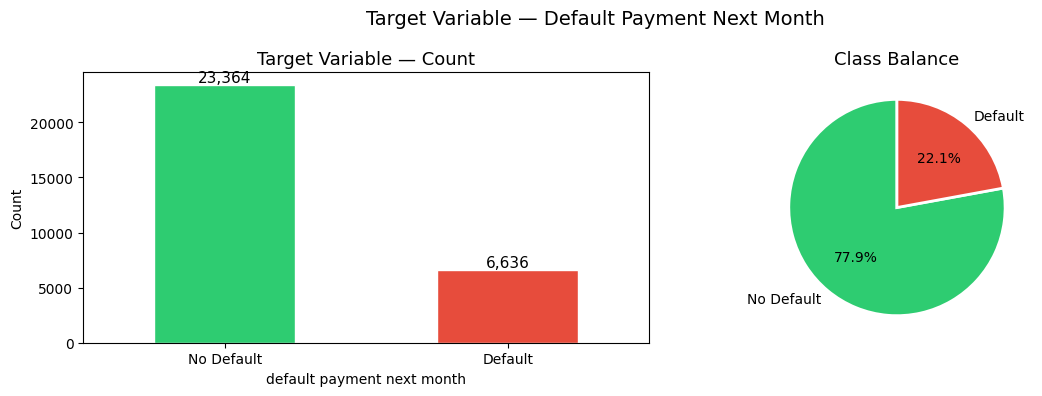

In [5]:
print("="*65)
print("Target variable analysis")
print("="*55)
target=df['default payment next month']
print(f"Unique values: {sorted(target.unique())}")
print(f"\nValue counts: ")
print(target.value_counts().sort_index())
print(f"\nClass balance: ")
for val,count in target.value_counts().sort_index().items():
    pct=count/len(df)*100
    label='No default' if val==0 else 'Default'
    print(f" {label} ({val}):{count:,} ({pct:.1f}%)")
fig,axes=plt.subplots(1,2,figsize=(12,4))
target.value_counts().sort_index().plot(
    kind='bar', ax=axes[0],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white', width=0.5
)
axes[0].set_title('Target Variable — Count', fontsize=13)
axes[0].set_xticklabels(['No Default', 'Default'], rotation=0)
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, 
                      p.get_height()),
                     ha='center', va='bottom', fontsize=11)

axes[1].pie(
    target.value_counts().sort_index(),
    labels=['No Default', 'Default'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Balance', fontsize=13)

plt.suptitle('Target Variable — Default Payment Next Month',
             fontsize=14)
plt.tight_layout()
plt.show()


## Phase 4 — Prepare the Data

Steps:
1. Clean data (handle noise in categorical columns)
2. Engineer temporal features (payment delay trend, utilization 
   change, spending volatility, repayment ratio)
3. Engineer labels (stress level + escalation)
4. Encode categorical features
5. Scale numerical features
6. Build preprocessing pipeline
7. Split into train and test sets

In [6]:
print("=" * 55)
print("CATEGORICAL FEATURES INSPECTION")
print("=" * 55)

cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']

for col in cat_cols:
    print(f"\n── {col} ──────────────────────────────────────")
    vc = df[col].value_counts().sort_index()
    for val, count in vc.items():
        pct = count / len(df) * 100
        print(f"  Value {val}: {count:,}  ({pct:.1f}%)")

print("\n\n" + "=" * 55)
print("PAY STATUS FEATURES INSPECTION")
print("=" * 55)

pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

for col in pay_cols:
    print(f"\n── {col} ──────────────────────────────────────")
    vc = df[col].value_counts().sort_index()
    for val, count in vc.items():
        pct = count / len(df) * 100
        print(f"  Value {val:3d}: {count:,}  ({pct:.1f}%)")

print("\n\n" + "=" * 55)
print("NEGATIVE BILL AMOUNTS CHECK")
print("=" * 55)

bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3',
             'BILL_AMT4','BILL_AMT5','BILL_AMT6']

for col in bill_cols:
    neg_count = (df[col] < 0).sum()
    pct = neg_count / len(df) * 100
    print(f"  {col}: {neg_count:,} negative values ({pct:.1f}%)")

CATEGORICAL FEATURES INSPECTION

── SEX ──────────────────────────────────────
  Value 1: 11,888  (39.6%)
  Value 2: 18,112  (60.4%)

── EDUCATION ──────────────────────────────────────
  Value 0: 14  (0.0%)
  Value 1: 10,585  (35.3%)
  Value 2: 14,030  (46.8%)
  Value 3: 4,917  (16.4%)
  Value 4: 123  (0.4%)
  Value 5: 280  (0.9%)
  Value 6: 51  (0.2%)

── MARRIAGE ──────────────────────────────────────
  Value 0: 54  (0.2%)
  Value 1: 13,659  (45.5%)
  Value 2: 15,964  (53.2%)
  Value 3: 323  (1.1%)


PAY STATUS FEATURES INSPECTION

── PAY_0 ──────────────────────────────────────
  Value  -2: 2,759  (9.2%)
  Value  -1: 5,686  (19.0%)
  Value   0: 14,737  (49.1%)
  Value   1: 3,688  (12.3%)
  Value   2: 2,667  (8.9%)
  Value   3: 322  (1.1%)
  Value   4: 76  (0.3%)
  Value   5: 26  (0.1%)
  Value   6: 11  (0.0%)
  Value   7: 9  (0.0%)
  Value   8: 19  (0.1%)

── PAY_2 ──────────────────────────────────────
  Value  -2: 3,782  (12.6%)
  Value  -1: 6,050  (20.2%)
  Value   0: 15,730  (5

In [7]:
print("=" * 55)
print("DATA CLEANING")
print("=" * 55)

df_clean = df.copy()

# ── 1. Drop ID ────────────────────────────────────────
df_clean = df_clean.drop('ID', axis=1)
print("✓ Dropped ID column (not a feature)")

# ── 2. Rename target ──────────────────────────────────
df_clean = df_clean.rename(
    columns={'default payment next month': 'default'}
)
print("✓ Renamed target to 'default'")

# ── 3. Fix EDUCATION undocumented values ──────────────
before = df_clean['EDUCATION'].value_counts().sort_index()
df_clean['EDUCATION'] = df_clean['EDUCATION'].replace(
    {0: 4, 5: 4, 6: 4}
)
after = df_clean['EDUCATION'].value_counts().sort_index()
print(f"\n✓ EDUCATION remapped (0,5,6 → 4)")
print(f"  Before unique values: {sorted(before.index.tolist())}")
print(f"  After unique values : {sorted(after.index.tolist())}")
print(f"  Category 4 count    : {before.get(4,0)} → {after.get(4,0)}")

# ── 4. Fix MARRIAGE undocumented values ───────────────
before_m = df_clean['MARRIAGE'].value_counts().sort_index()
df_clean['MARRIAGE'] = df_clean['MARRIAGE'].replace({0: 3})
after_m = df_clean['MARRIAGE'].value_counts().sort_index()
print(f"\n✓ MARRIAGE remapped (0 → 3)")
print(f"  Before unique values: {sorted(before_m.index.tolist())}")
print(f"  After unique values : {sorted(after_m.index.tolist())}")
print(f"  Category 3 count    : {before_m.get(3,0)} → {after_m.get(3,0)}")

# ── 5. Cap PAY_AMT outliers at 99th percentile ────────
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                'PAY_AMT4','PAY_AMT5','PAY_AMT6']
print(f"\n✓ Capping PAY_AMT outliers at 99th percentile:")
for col in pay_amt_cols:
    cap = df_clean[col].quantile(0.99)
    outliers_before = (df_clean[col] > cap).sum()
    df_clean[col] = df_clean[col].clip(upper=cap)
    print(f"  {col}: capped at {cap:,.0f}  "
          f"({outliers_before} rows affected)")

# ── 6. Verify final state ─────────────────────────────
print(f"\n── Final Clean Dataset ─────────────────────────────")
print(f"  Shape        : {df_clean.shape}")
print(f"  Missing values: {df_clean.isnull().sum().sum()}")
print(f"  Columns      : {list(df_clean.columns)}")

DATA CLEANING
✓ Dropped ID column (not a feature)
✓ Renamed target to 'default'

✓ EDUCATION remapped (0,5,6 → 4)
  Before unique values: [0, 1, 2, 3, 4, 5, 6]
  After unique values : [1, 2, 3, 4]
  Category 4 count    : 123 → 468

✓ MARRIAGE remapped (0 → 3)
  Before unique values: [0, 1, 2, 3]
  After unique values : [1, 2, 3]
  Category 3 count    : 323 → 377

✓ Capping PAY_AMT outliers at 99th percentile:
  PAY_AMT1: capped at 66,522  (300 rows affected)
  PAY_AMT2: capped at 76,651  (300 rows affected)
  PAY_AMT3: capped at 70,000  (297 rows affected)
  PAY_AMT4: capped at 67,054  (300 rows affected)
  PAY_AMT5: capped at 65,608  (300 rows affected)
  PAY_AMT6: capped at 82,619  (300 rows affected)

── Final Clean Dataset ─────────────────────────────
  Shape        : (30000, 24)
  Missing values: 0
  Columns      : ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AM

In [8]:
print("=" * 55)
print("TEMPORAL FEATURE ENGINEERING")
print("=" * 55)

df_feat = df_clean.copy()

bill_cols    = ['BILL_AMT1','BILL_AMT2','BILL_AMT3',
                'BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_cols     = ['PAY_0','PAY_2','PAY_3',
                'PAY_4','PAY_5','PAY_6']
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                'PAY_AMT4','PAY_AMT5','PAY_AMT6']

# ── 1. Monthly utilization ────────────────────────────
for i, col in enumerate(bill_cols, 1):
    df_feat[f'UTIL_{i}'] = (
        df_feat[col] / df_feat['LIMIT_BAL'].replace(0, np.nan)
    ).clip(0, 1).fillna(0)

util_cols = [f'UTIL_{i}' for i in range(1, 7)]
print("✓ Monthly utilization created (UTIL_1 to UTIL_6)")

# ── 2. Average utilization ────────────────────────────
df_feat['avg_utilization'] = df_feat[util_cols].mean(axis=1)
print("✓ avg_utilization created")

# ── 3. Utilization change (recent vs early) ───────────
df_feat['util_recent'] = df_feat[['UTIL_1','UTIL_2']].mean(axis=1)
df_feat['util_early']  = df_feat[['UTIL_5','UTIL_6']].mean(axis=1)
df_feat['util_change'] = (df_feat['util_recent'] 
                          - df_feat['util_early'])
print("✓ util_change created (recent - early)")

# ── 4. Payment delay trend (slope over 6 months) ──────
pay_matrix = df_feat[pay_cols].values.astype(float)
x = np.arange(len(pay_cols))
# polyfit returns [slope, intercept] — we want slope only
slopes = np.array([
    np.polyfit(x, row, 1)[0] for row in pay_matrix
])
df_feat['pay_delay_trend'] = slopes
print("✓ pay_delay_trend created (slope of PAY over time)")

# ── 5. Average payment delay ──────────────────────────
df_feat['avg_pay_delay'] = df_feat[pay_cols].mean(axis=1)
print("✓ avg_pay_delay created")

# ── 6. Consecutive delay count ────────────────────────
df_feat['consecutive_delays'] = (
    df_feat[pay_cols].gt(0).sum(axis=1)
)
print("✓ consecutive_delays created (months with delay > 0)")

# ── 7. Monthly repayment ratio ────────────────────────
for i, (p, b) in enumerate(zip(pay_amt_cols, bill_cols), 1):
    df_feat[f'REPAY_RATIO_{i}'] = np.where(
        df_feat[b] > 0,
        (df_feat[p] / df_feat[b]).clip(0, 1),
        1.0  # if no bill, considered fully repaid
    )

repay_cols = [f'REPAY_RATIO_{i}' for i in range(1, 7)]
print("✓ Monthly repayment ratios created (REPAY_RATIO_1 to 6)")

# ── 8. Average repayment ratio ────────────────────────
df_feat['avg_repay_ratio'] = df_feat[repay_cols].mean(axis=1)
print("✓ avg_repay_ratio created")

# ── 9. Spending volatility ────────────────────────────
df_feat['spending_volatility'] = df_feat[bill_cols].std(axis=1)
print("✓ spending_volatility created (std of BILL_AMT)")

# ── 10. Payment amount trend ──────────────────────────
pay_amt_matrix = df_feat[pay_amt_cols].values.astype(float)
pay_slopes = np.array([
    np.polyfit(x, row, 1)[0] for row in pay_amt_matrix
])
df_feat['pay_amt_trend'] = pay_slopes
print("✓ pay_amt_trend created (slope of PAY_AMT over time)")

# ── Summary ───────────────────────────────────────────
new_features = (util_cols + ['avg_utilization', 'util_change',
                'pay_delay_trend', 'avg_pay_delay',
                'consecutive_delays'] + repay_cols +
                ['avg_repay_ratio', 'spending_volatility',
                 'pay_amt_trend'])

print(f"\n── Feature Engineering Summary ─────────────────────")
print(f"  Original features : {df_clean.shape[1] - 1}")
print(f"  New features added: {len(new_features)}")
print(f"  Total features    : {df_feat.shape[1] - 1}")

print(f"\n── New Feature Statistics ──────────────────────────")
print(df_feat[new_features].describe().T[
    ['mean','std','min','max']
].round(4))

TEMPORAL FEATURE ENGINEERING
✓ Monthly utilization created (UTIL_1 to UTIL_6)
✓ avg_utilization created
✓ util_change created (recent - early)
✓ pay_delay_trend created (slope of PAY over time)
✓ avg_pay_delay created
✓ consecutive_delays created (months with delay > 0)
✓ Monthly repayment ratios created (REPAY_RATIO_1 to 6)
✓ avg_repay_ratio created
✓ spending_volatility created (std of BILL_AMT)
✓ pay_amt_trend created (slope of PAY_AMT over time)

── Feature Engineering Summary ─────────────────────
  Original features : 23
  New features added: 20
  Total features    : 45

── New Feature Statistics ──────────────────────────
                         mean       std        min        max
UTIL_1                  0.415     0.387      0.000      1.000
UTIL_2                  0.404     0.384      0.000      1.000
UTIL_3                  0.386     0.375      0.000      1.000
UTIL_4                  0.356     0.356      0.000      1.000
UTIL_5                  0.330     0.340      0.000   

In [9]:
print("=" * 55)
print("LOG TRANSFORM + LABEL ENGINEERING")
print("=" * 55)

# ── Log transform spending_volatility ─────────────────
# Adding 1 to handle zeros (log(0) is undefined)
df_feat['spending_volatility'] = np.log1p(
    df_feat['spending_volatility']
)
print("✓ Log1p transform applied to spending_volatility")
print(f"  New range: "
      f"{df_feat['spending_volatility'].min():.3f} to "
      f"{df_feat['spending_volatility'].max():.3f}")
print(f"  New mean : {df_feat['spending_volatility'].mean():.3f}")

# ── Log transform pay_amt_trend (has negatives) ────────
# Signed log: preserves direction, compresses scale
df_feat['pay_amt_trend'] = np.sign(df_feat['pay_amt_trend']) * \
    np.log1p(np.abs(df_feat['pay_amt_trend']))
print("\n✓ Signed log transform applied to pay_amt_trend")
print(f"  New range: "
      f"{df_feat['pay_amt_trend'].min():.3f} to "
      f"{df_feat['pay_amt_trend'].max():.3f}")
print(f"  New mean : {df_feat['pay_amt_trend'].mean():.3f}")

print("\n" + "=" * 55)
print("LABEL ENGINEERING")
print("=" * 55)

# ── Stress Label (Task A — 3 class) ───────────────────
def assign_stress_label(row):
    if row['PAY_0'] >= 2 or row['avg_utilization'] > 0.80:
        return 2   # High
    elif (row['PAY_0'] == 1 or 
          (0.50 < row['avg_utilization'] <= 0.80)):
        return 1   # Medium
    else:
        return 0   # Low

df_feat['stress_label'] = df_feat.apply(
    assign_stress_label, axis=1
)

stress_map = {0: 'Low', 1: 'Medium', 2: 'High'}
print("\nStress Label Distribution:")
for k in sorted(df_feat['stress_label'].unique()):
    count = (df_feat['stress_label'] == k).sum()
    pct   = count / len(df_feat) * 100
    print(f"  {stress_map[k]:8s} ({k}): "
          f"{count:,}  ({pct:.1f}%)")

# ── Escalation Label (Task B — binary) ────────────────
def assign_escalation_label(row):
    pay_recent = (row['PAY_0'] + row['PAY_2']) / 2
    pay_early  = (row['PAY_5'] + row['PAY_6']) / 2
    delay_escalating = pay_recent > pay_early
    util_escalating  = row['util_change'] > 0.15
    return 1 if (delay_escalating or util_escalating) else 0

df_feat['escalation_label'] = df_feat.apply(
    assign_escalation_label, axis=1
)

esc_map = {0: 'Stable', 1: 'Escalating'}
print("\nEscalation Label Distribution:")
for k in sorted(df_feat['escalation_label'].unique()):
    count = (df_feat['escalation_label'] == k).sum()
    pct   = count / len(df_feat) * 100
    print(f"  {esc_map[k]:12s} ({k}): "
          f"{count:,}  ({pct:.1f}%)")

# ── Cross check labels vs actual default ──────────────
print("\n── Label vs Actual Default Cross Check ─────────────")
print("\nStress vs Default:")
print(pd.crosstab(
    df_feat['stress_label'].map(stress_map),
    df_feat['default'],
    colnames=['Default'],
    rownames=['Stress']
))

print("\nEscalation vs Default:")
print(pd.crosstab(
    df_feat['escalation_label'].map(esc_map),
    df_feat['default'],
    colnames=['Default'],
    rownames=['Escalation']
))

LOG TRANSFORM + LABEL ENGINEERING
✓ Log1p transform applied to spending_volatility
  New range: 0.000 to 13.381
  New mean : 8.166

✓ Signed log transform applied to pay_amt_trend
  New range: -9.782 to 9.752
  New mean : -1.867

LABEL ENGINEERING

Stress Label Distribution:
  Low      (0): 15,324  (51.1%)
  Medium   (1): 7,770  (25.9%)
  High     (2): 6,906  (23.0%)

Escalation Label Distribution:
  Stable       (0): 16,624  (55.4%)
  Escalating   (1): 13,376  (44.6%)

── Label vs Actual Default Cross Check ─────────────

Stress vs Default:
Default      0     1
Stress              
High      3919  2987
Low      13354  1970
Medium    6091  1679

Escalation vs Default:
Default         0     1
Escalation             
Escalating   9816  3560
Stable      13548  3076


LABEL VISUALIZATIONS


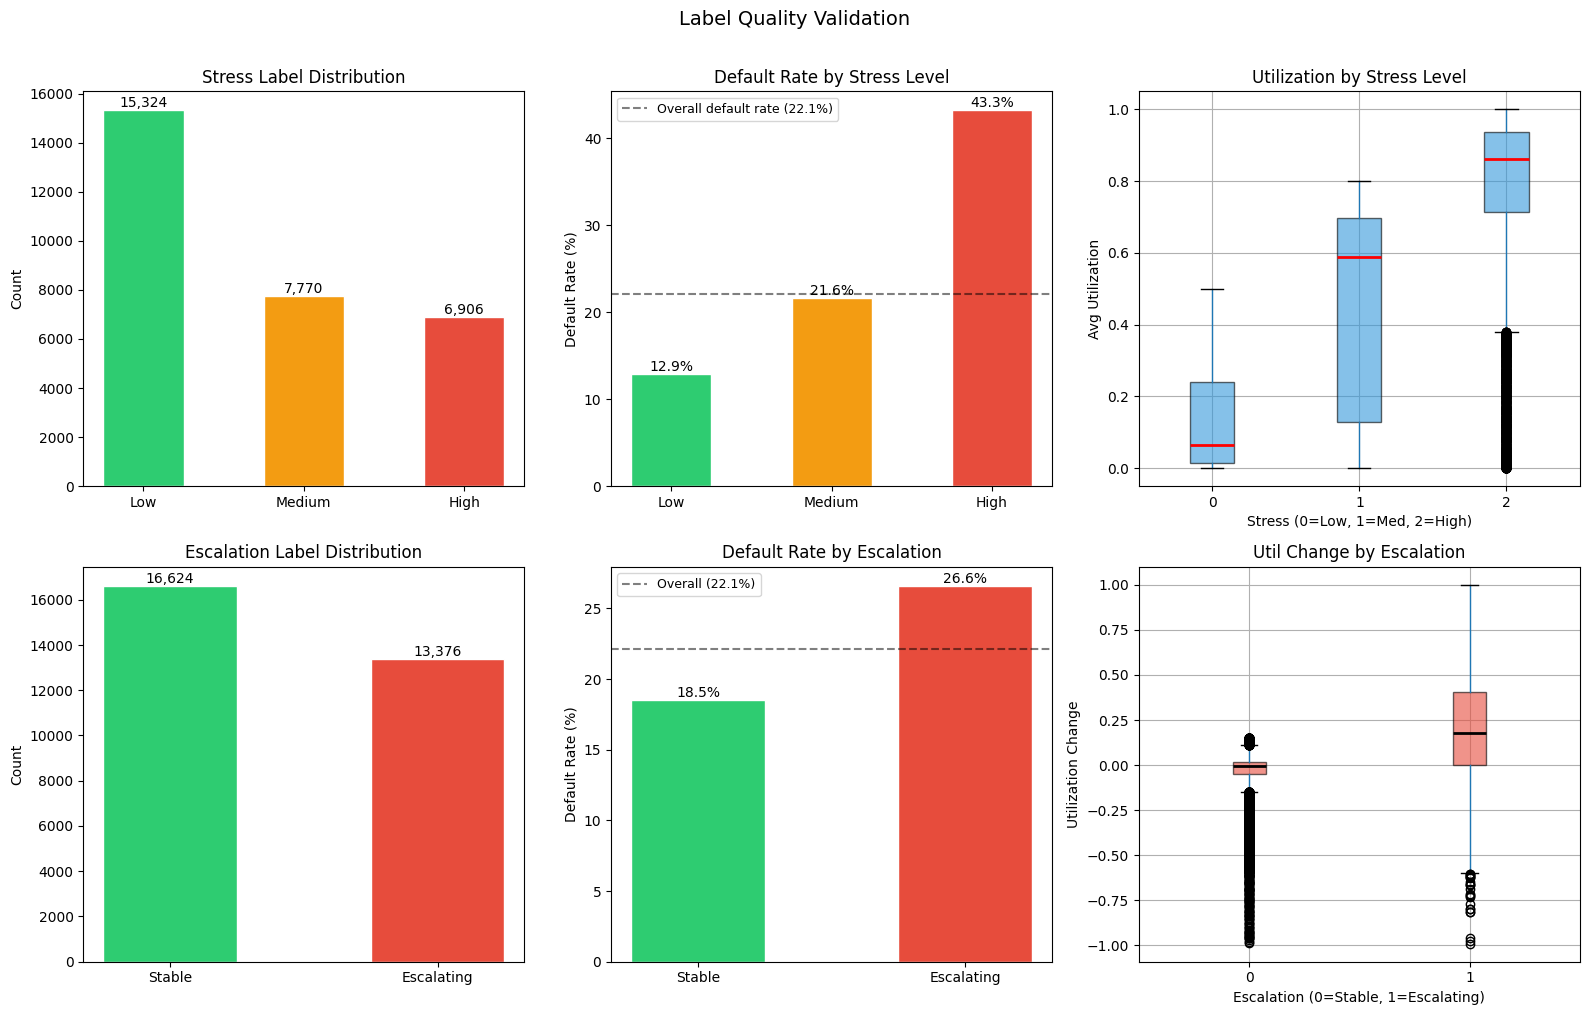


✓ Label validation complete
  Stress label    : monotonically increasing default rate ✓
  Escalation label: higher default rate for escalating ✓
  Both labels are meaningful and ready for training


In [10]:
print("=" * 55)
print("LABEL VISUALIZATIONS")
print("=" * 55)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── Row 1: Stress label analysis ──────────────────────
# Plot 1: Stress distribution
stress_counts = df_feat['stress_label'].map(
    stress_map).value_counts()
colors_stress = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0][0].bar(
    ['Low', 'Medium', 'High'],
    [df_feat['stress_label'].eq(0).sum(),
     df_feat['stress_label'].eq(1).sum(),
     df_feat['stress_label'].eq(2).sum()],
    color=colors_stress, edgecolor='white', width=0.5
)
axes[0][0].set_title('Stress Label Distribution', fontsize=12)
axes[0][0].set_ylabel('Count')
for p in axes[0][0].patches:
    axes[0][0].annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

# Plot 2: Default rate by stress level
default_rates_stress = [
    df_feat[df_feat['stress_label']==0]['default'].mean(),
    df_feat[df_feat['stress_label']==1]['default'].mean(),
    df_feat[df_feat['stress_label']==2]['default'].mean()
]
bars = axes[0][1].bar(
    ['Low', 'Medium', 'High'],
    [r*100 for r in default_rates_stress],
    color=colors_stress, edgecolor='white', width=0.5
)
axes[0][1].set_title('Default Rate by Stress Level', fontsize=12)
axes[0][1].set_ylabel('Default Rate (%)')
axes[0][1].axhline(y=22.1, color='black',
                    linestyle='--', alpha=0.5,
                    label='Overall default rate (22.1%)')
axes[0][1].legend(fontsize=9)
for p in axes[0][1].patches:
    axes[0][1].annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

# Plot 3: avg_utilization by stress level
df_feat.boxplot(
    column='avg_utilization',
    by='stress_label',
    ax=axes[0][2],
    patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.6),
    medianprops=dict(color='red', linewidth=2)
)
axes[0][2].set_title('Utilization by Stress Level', fontsize=12)
axes[0][2].set_xlabel('Stress (0=Low, 1=Med, 2=High)')
axes[0][2].set_ylabel('Avg Utilization')
plt.sca(axes[0][2])
plt.title('Utilization by Stress Level', fontsize=12)

# ── Row 2: Escalation label analysis ──────────────────
colors_esc = ['#2ecc71', '#e74c3c']

# Plot 4: Escalation distribution
axes[1][0].bar(
    ['Stable', 'Escalating'],
    [df_feat['escalation_label'].eq(0).sum(),
     df_feat['escalation_label'].eq(1).sum()],
    color=colors_esc, edgecolor='white', width=0.5
)
axes[1][0].set_title('Escalation Label Distribution', fontsize=12)
axes[1][0].set_ylabel('Count')
for p in axes[1][0].patches:
    axes[1][0].annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

# Plot 5: Default rate by escalation
default_rates_esc = [
    df_feat[df_feat['escalation_label']==0]['default'].mean(),
    df_feat[df_feat['escalation_label']==1]['default'].mean()
]
axes[1][1].bar(
    ['Stable', 'Escalating'],
    [r*100 for r in default_rates_esc],
    color=colors_esc, edgecolor='white', width=0.5
)
axes[1][1].set_title('Default Rate by Escalation', fontsize=12)
axes[1][1].set_ylabel('Default Rate (%)')
axes[1][1].axhline(y=22.1, color='black',
                    linestyle='--', alpha=0.5,
                    label='Overall (22.1%)')
axes[1][1].legend(fontsize=9)
for p in axes[1][1].patches:
    axes[1][1].annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

# Plot 6: util_change by escalation
df_feat.boxplot(
    column='util_change',
    by='escalation_label',
    ax=axes[1][2],
    patch_artist=True,
    boxprops=dict(facecolor='#e74c3c', alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)
axes[1][2].set_title('Util Change by Escalation', fontsize=12)
axes[1][2].set_xlabel('Escalation (0=Stable, 1=Escalating)')
axes[1][2].set_ylabel('Utilization Change')
plt.sca(axes[1][2])
plt.title('Util Change by Escalation', fontsize=12)

plt.suptitle('Label Quality Validation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\n✓ Label validation complete")
print("  Stress label    : monotonically increasing default rate ✓")
print("  Escalation label: higher default rate for escalating ✓")
print("  Both labels are meaningful and ready for training")

CORRELATION ANALYSIS

Correlation with STRESS LABEL:
---------------------------------------------
  avg_utilization           +0.7540  ██████████████████████
  util_early                +0.7317  █████████████████████
  util_recent               +0.6819  ████████████████████
  avg_pay_delay             +0.5714  █████████████████
  consecutive_delays        +0.4931  ██████████████
  util_change               +0.0654  █
  spending_volatility       +0.0030  
  AGE                       -0.0242  
  pay_amt_trend             -0.0547  █
  pay_delay_trend           -0.1927  █████
  LIMIT_BAL                 -0.3350  ██████████
  avg_repay_ratio           -0.4954  ██████████████

Correlation with ESCALATION LABEL:
---------------------------------------------
  util_change               +0.5355  ████████████████
  util_recent               +0.2950  ████████
  spending_volatility       +0.1683  █████
  avg_utilization           +0.1384  ████
  avg_pay_delay             +0.0912  ██
  consecutive

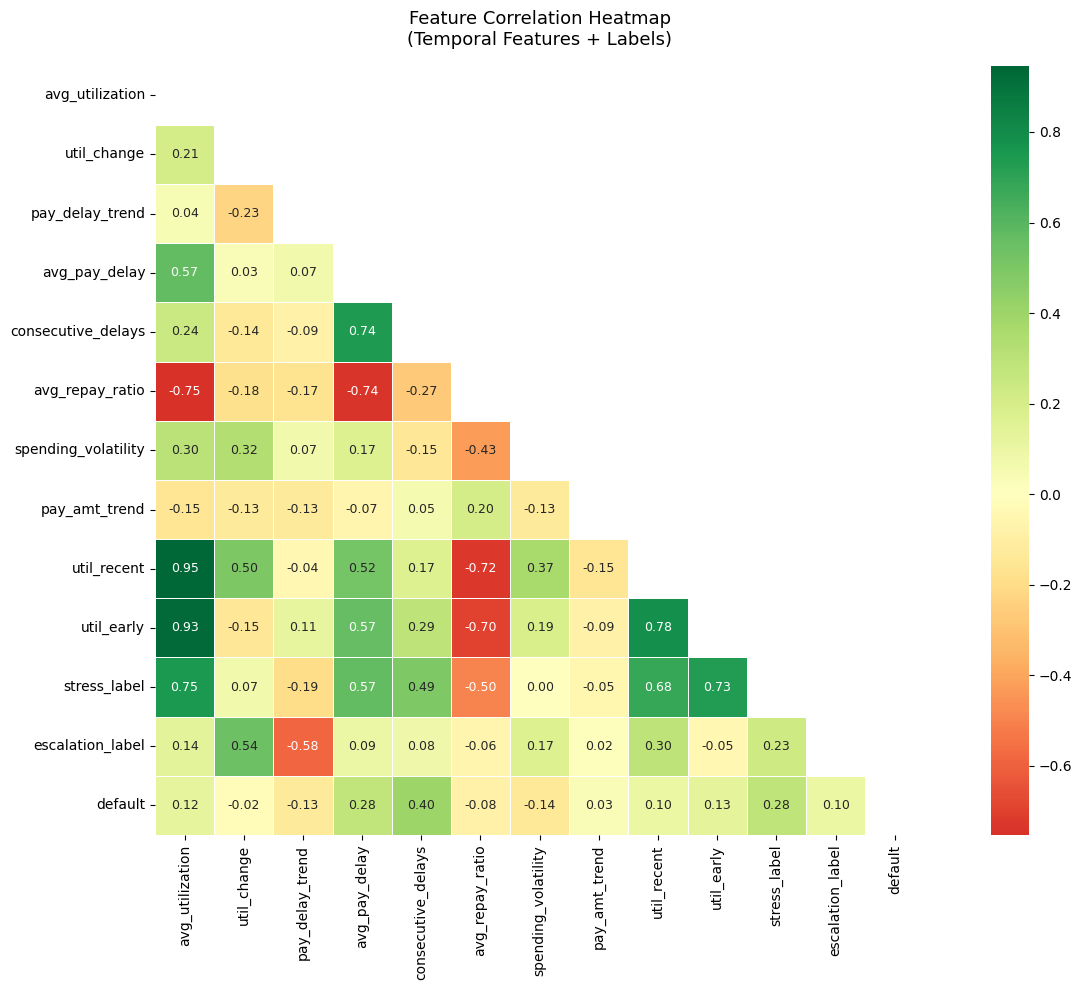

In [11]:
print("=" * 55)
print("CORRELATION ANALYSIS")
print("=" * 55)

# Features to analyze
temporal_features = [
    'avg_utilization', 'util_change', 'pay_delay_trend',
    'avg_pay_delay', 'consecutive_delays', 'avg_repay_ratio',
    'spending_volatility', 'pay_amt_trend',
    'util_recent', 'util_early'
]
static_features = ['LIMIT_BAL', 'AGE']

all_analysis_features = temporal_features + static_features

# ── Correlation with stress label ─────────────────────
print("\nCorrelation with STRESS LABEL:")
print("-" * 45)
corr_stress = df_feat[all_analysis_features].corrwith(
    df_feat['stress_label']
).sort_values(ascending=False)
for feat, val in corr_stress.items():
    bar = '█' * int(abs(val) * 30)
    direction = '+' if val > 0 else '-'
    print(f"  {feat:<25} {direction}{abs(val):.4f}  {bar}")

# ── Correlation with escalation label ─────────────────
print("\nCorrelation with ESCALATION LABEL:")
print("-" * 45)
corr_esc = df_feat[all_analysis_features].corrwith(
    df_feat['escalation_label']
).sort_values(ascending=False)
for feat, val in corr_esc.items():
    bar = '█' * int(abs(val) * 30)
    direction = '+' if val > 0 else '-'
    print(f"  {feat:<25} {direction}{abs(val):.4f}  {bar}")

# ── Correlation with actual default ───────────────────
print("\nCorrelation with ACTUAL DEFAULT:")
print("-" * 45)
corr_default = df_feat[all_analysis_features].corrwith(
    df_feat['default']
).sort_values(ascending=False)
for feat, val in corr_default.items():
    bar = '█' * int(abs(val) * 30)
    direction = '+' if val > 0 else '-'
    print(f"  {feat:<25} {direction}{abs(val):.4f}  {bar}")

# ── Heatmap of temporal features ──────────────────────
plt.figure(figsize=(14, 10))
corr_matrix = df_feat[
    temporal_features + ['stress_label', 
                         'escalation_label', 'default']
].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5,
    annot_kws={'size': 9},
    square=True
)
plt.title('Feature Correlation Heatmap\n'
          '(Temporal Features + Labels)',
          fontsize=13, pad=15)
plt.tight_layout()
plt.show()

In [12]:
print("=" * 55)
print("FEATURE SELECTION + ENCODING + SPLIT + SCALE")
print("=" * 55)

# ── Final feature set ─────────────────────────────────
temporal_final = [
    'avg_utilization',    # strongest stress signal
    'util_change',        # strongest escalation signal  
    'avg_pay_delay',      # strong for both tasks
    'consecutive_delays', # strongest default predictor
    'avg_repay_ratio',    # strong negative stress signal
    'spending_volatility',# contributes to escalation
    'pay_delay_trend',    # key escalation signal
    'pay_amt_trend',      # independent signal
    'LIMIT_BAL',          # meaningful negative correlation
]
categorical_final = ['SEX', 'EDUCATION', 'MARRIAGE']

# AGE dropped — near zero correlation with all targets
# util_recent dropped — 0.95 correlated with avg_utilization
# util_early dropped  — 0.93 correlated with avg_utilization

print(f"✓ Features selected: {len(temporal_final)} temporal "
      f"+ {len(categorical_final)} categorical")
print(f"  Dropped: AGE (near-zero correlation)")
print(f"  Dropped: util_recent (0.95 with avg_utilization)")
print(f"  Dropped: util_early  (0.93 with avg_utilization)")

# ── Build model dataframe ─────────────────────────────
feature_cols = temporal_final + categorical_final
df_model = df_feat[
    feature_cols + ['stress_label', 
                    'escalation_label', 'default']
].copy()

print(f"\n✓ Model dataframe shape: {df_model.shape}")

# ── One-hot encode categoricals ───────────────────────
df_model = pd.get_dummies(
    df_model,
    columns=categorical_final,
    drop_first=True
)
print(f"✓ Categorical features encoded")
print(f"  Shape after encoding: {df_model.shape}")
print(f"  New columns added: "
      f"{[c for c in df_model.columns if any(cat in c for cat in categorical_final)]}")

# ── Define X and y for Task A (Stress — LR task) ──────
feature_columns = [c for c in df_model.columns 
                   if c not in ['stress_label', 
                                'escalation_label', 
                                'default']]
X = df_model[feature_columns]
y = df_model['stress_label']

print(f"\n✓ X shape: {X.shape}")
print(f"✓ y shape: {y.shape}")
print(f"✓ Features: {list(X.columns)}")

# ── Stratified train/test split ───────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"\n✓ Train/Test split — 80/20 stratified")
print(f"  X_train: {X_train.shape}")
print(f"  X_test : {X_test.shape}")
print(f"\n  Train class distribution:")
for k, v in sorted(y_train.value_counts().items()):
    pct = v/len(y_train)*100
    print(f"    {stress_map[k]:8s}: {v:,} ({pct:.1f}%)")
print(f"\n  Test class distribution:")
for k, v in sorted(y_test.value_counts().items()):
    pct = v/len(y_test)*100
    print(f"    {stress_map[k]:8s}: {v:,} ({pct:.1f}%)")

# ── Scale features ────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to dataframe for readability
X_train_scaled = pd.DataFrame(
    X_train_scaled, 
    columns=feature_columns
)
X_test_scaled = pd.DataFrame(
    X_test_scaled,  
    columns=feature_columns
)

print(f"\n✓ StandardScaler applied")
print(f"  Fitted on train only — no data leakage")
print(f"\n  Sample scaled values (first row):")
print(X_train_scaled.iloc[0].round(4))

FEATURE SELECTION + ENCODING + SPLIT + SCALE
✓ Features selected: 9 temporal + 3 categorical
  Dropped: AGE (near-zero correlation)
  Dropped: util_recent (0.95 with avg_utilization)
  Dropped: util_early  (0.93 with avg_utilization)

✓ Model dataframe shape: (30000, 15)
✓ Categorical features encoded
  Shape after encoding: (30000, 18)
  New columns added: ['SEX_2', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']

✓ X shape: (30000, 15)
✓ y shape: (30000,)
✓ Features: ['avg_utilization', 'util_change', 'avg_pay_delay', 'consecutive_delays', 'avg_repay_ratio', 'spending_volatility', 'pay_delay_trend', 'pay_amt_trend', 'LIMIT_BAL', 'SEX_2', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']

✓ Train/Test split — 80/20 stratified
  X_train: (24000, 15)
  X_test : (6000, 15)

  Train class distribution:
    Low     : 12,259 (51.1%)
    Medium  : 6,216 (25.9%)
    High    : 5,525 (23.0%)

  Test class distribution:
    Low     : 3,065 (51.1%)


## Phase 5 — Shortlist Models

Training Logistic Regression with cross-validation.
Comparing performance across multiple configurations
to select the best setup before fine-tuning.

PHASE 5 — SHORTLIST MODELS (CROSS VALIDATION)

Running 5-fold stratified cross validation...
Metric: Weighted F1 Score
────────────────────────────────────────────────────────────
Configuration                     Mean F1     Std F1     Min F1     Max F1
────────────────────────────────────────────────────────────
LR — default                       0.8581     0.0066     0.8515     0.8704
LR — balanced                      0.8634     0.0057     0.8578     0.8719
LR — balanced + C=0.1              0.8622     0.0059     0.8553     0.8720
LR — balanced + C=10               0.8634     0.0058     0.8576     0.8721
────────────────────────────────────────────────────────────

✓ Best configuration: LR — balanced + C=10
  Mean F1: 0.8634
  Std F1 : 0.0058


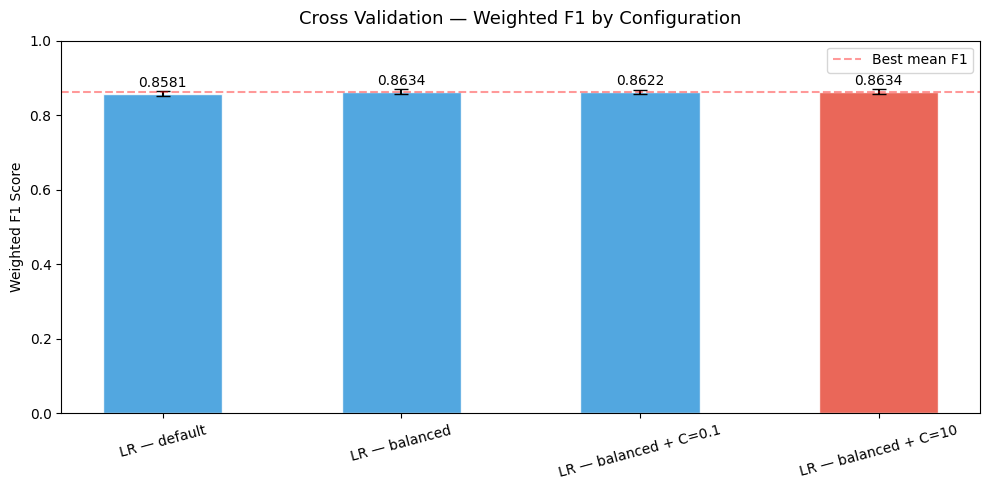

In [13]:
print("=" * 55)
print("PHASE 5 — SHORTLIST MODELS (CROSS VALIDATION)")
print("=" * 55)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Three configurations to compare
configs = {
    'LR — default' : LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    'LR — balanced' : LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ),
    'LR — balanced + C=0.1' : LogisticRegression(
        class_weight='balanced',
        C=0.1,
        random_state=42,
        max_iter=1000
    ),
    'LR — balanced + C=10' : LogisticRegression(
        class_weight='balanced',
        C=10,
        random_state=42,
        max_iter=1000
    ),
}

print(f"\nRunning 5-fold stratified cross validation...")
print(f"Metric: Weighted F1 Score")
print(f"{'─'*60}")
print(f"{'Configuration':<30} {'Mean F1':>10} "
      f"{'Std F1':>10} {'Min F1':>10} {'Max F1':>10}")
print(f"{'─'*60}")

results = {}
for name, model in configs.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1
    )
    results[name] = scores
    print(f"{name:<30} {scores.mean():>10.4f} "
          f"{scores.std():>10.4f} "
          f"{scores.min():>10.4f} "
          f"{scores.max():>10.4f}")

print(f"{'─'*60}")
best_config = max(results, key=lambda k: results[k].mean())
print(f"\n✓ Best configuration: {best_config}")
print(f"  Mean F1: {results[best_config].mean():.4f}")
print(f"  Std F1 : {results[best_config].std():.4f}")

# Visualize CV results
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(results.keys())
means  = [results[n].mean() for n in names]
stds   = [results[n].std()  for n in names]
colors = ['#e74c3c' if n == best_config 
          else '#3498db' for n in names]

bars = ax.bar(names, means, yerr=stds, 
              color=colors, edgecolor='white',
              capsize=5, width=0.5, alpha=0.85)
ax.set_title('Cross Validation — Weighted F1 by Configuration',
             fontsize=13, pad=12)
ax.set_ylabel('Weighted F1 Score')
ax.set_ylim(0, 1.0)
ax.tick_params(axis='x', rotation=15)
for bar, mean in zip(bars, means):
    ax.annotate(f'{mean:.4f}',
                (bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01),
                ha='center', va='bottom', fontsize=10)

ax.axhline(y=max(means), color='red', 
           linestyle='--', alpha=0.4, label='Best mean F1')
ax.legend()
plt.tight_layout()
plt.show()

## Phase 6 — Fine-Tune and Evaluate

Hyperparameter tuning using RandomizedSearchCV.
Treating preprocessing choices as hyperparameters.
Final evaluation on held-out test set.

In [14]:
from sklearn.model_selection import RandomizedSearchCV

print("=" * 55)
print("PHASE 6 — HYPERPARAMETER FINE TUNING")
print("=" * 55)
print("Base: LR balanced + C=10 (best from Phase 5)")
print("Method: RandomizedSearchCV, 5-fold, 40 iterations")
print()

param_dist = {
    'C'            : [0.01, 0.05, 0.1, 0.5, 1, 
                      5, 10, 20, 50, 100],
    'penalty'      : ['l1', 'l2'],
    'solver'       : ['liblinear', 'saga'],
    'class_weight' : ['balanced'],
    'max_iter'     : [1000, 2000],
    'tol'          : [1e-4, 1e-3, 1e-2]
}

lr_base = LogisticRegression(random_state=42)

random_search = RandomizedSearchCV(
    estimator           = lr_base,
    param_distributions = param_dist,
    n_iter              = 40,
    cv                  = cv,
    scoring             = 'f1_weighted',
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1,
    return_train_score  = True
)

random_search.fit(X_train_scaled, y_train)

print(f"\n✓ Best parameters found:")
print(f"{'─'*40}")
for k, v in random_search.best_params_.items():
    print(f"  {k:<15}: {v}")

print(f"\n✓ Best CV F1  : {random_search.best_score_:.4f}")

# Show top 5 configurations
results_df = pd.DataFrame(random_search.cv_results_)
top5 = results_df.nlargest(5, 'mean_test_score')[
    ['param_C', 'param_penalty', 'param_solver',
     'param_tol', 'mean_test_score', 
     'std_test_score', 'mean_train_score']
].round(4)

print(f"\n── Top 5 Configurations ────────────────────────────")
print(top5.to_string(index=False))

# Overfitting check
best_idx = random_search.best_index_
train_score = results_df.loc[best_idx, 'mean_train_score']
test_score  = results_df.loc[best_idx, 'mean_test_score']
gap         = train_score - test_score

print(f"\n── Overfitting Check ───────────────────────────────")
print(f"  Train F1 : {train_score:.4f}")
print(f"  CV F1    : {test_score:.4f}")
print(f"  Gap      : {gap:.4f} "
      f"{'(healthy)' if gap < 0.05 else '(overfitting risk)'}")

best_lr = random_search.best_estimator_

PHASE 6 — HYPERPARAMETER FINE TUNING
Base: LR balanced + C=10 (best from Phase 5)
Method: RandomizedSearchCV, 5-fold, 40 iterations

Fitting 5 folds for each of 40 candidates, totalling 200 fits

✓ Best parameters found:
────────────────────────────────────────
  tol            : 0.0001
  solver         : saga
  penalty        : l2
  max_iter       : 2000
  class_weight   : balanced
  C              : 0.5

✓ Best CV F1  : 0.8633

── Top 5 Configurations ────────────────────────────
 param_C param_penalty param_solver  param_tol  mean_test_score  std_test_score  mean_train_score
   0.500            l2         saga      0.000            0.863           0.006             0.864
  20.000            l1         saga      0.001            0.863           0.006             0.864
  50.000            l2         saga      0.000            0.863           0.006             0.864
 100.000            l2         saga      0.000            0.863           0.006             0.864
  10.000            l2 

FINAL EVALUATION ON HELD-OUT TEST SET

Classification Report:
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

         Low     0.9621    0.9113    0.9360      3065
      Medium     0.7214    0.7947    0.7563      1554
        High     0.8404    0.8429    0.8416      1381

    accuracy                         0.8653      6000
   macro avg     0.8413    0.8496    0.8446      6000
weighted avg     0.8718    0.8653    0.8677      6000

── Summary Metrics ─────────────────────────────────
  Weighted F1     : 0.8677
  Macro F1        : 0.8446
  F1 — Low        : 0.9360
  F1 — Medium     : 0.7563
  F1 — High       : 0.8416


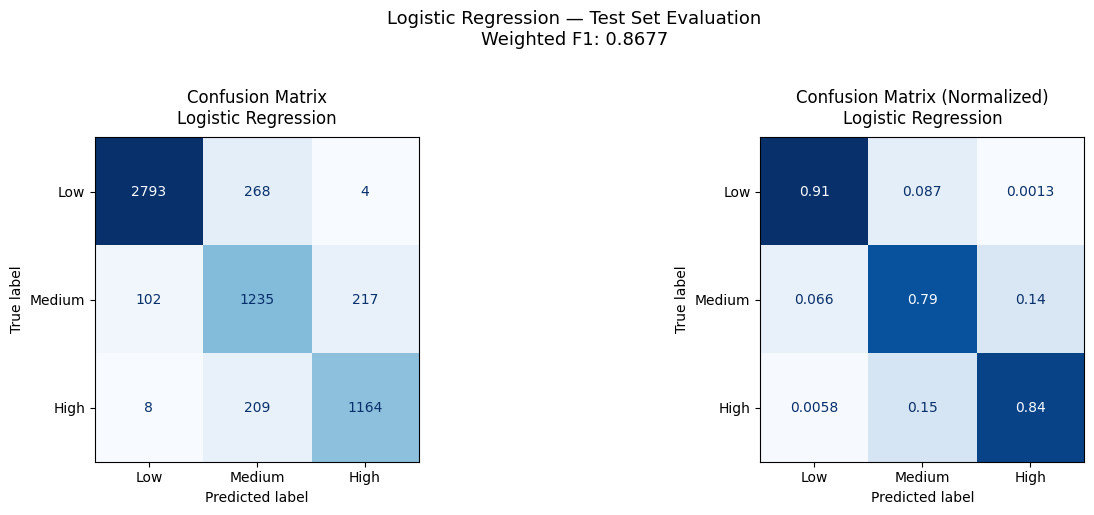


── Error Analysis ──────────────────────────────────
Where is the model making mistakes?

               Pred Low  Pred Medium  Pred High
Actual Low         2793          268          4
Actual Medium       102         1235        217
Actual High           8          209       1164

  Total errors     : 808 / 6,000
  Error rate       : 13.47%

  Most common misclassifications:
    Actual Low    → Predicted Medium: 268 cases
    Actual Medium → Predicted Low   : 102 cases
    Actual Medium → Predicted High  : 217 cases
    Actual High   → Predicted Medium: 209 cases


In [15]:
print("=" * 55)
print("FINAL EVALUATION ON HELD-OUT TEST SET")
print("=" * 55)

# Predict on test set
y_pred      = best_lr.predict(X_test_scaled)
y_pred_prob = best_lr.predict_proba(X_test_scaled)

# ── Classification Report ─────────────────────────────
print("\nClassification Report:")
print("─" * 55)
print(classification_report(
    y_test, y_pred,
    target_names=['Low', 'Medium', 'High'],
    digits=4
))

# ── Key Metrics ───────────────────────────────────────
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_macro    = f1_score(y_test, y_pred, average='macro')
f1_per_class = f1_score(y_test, y_pred, average=None)

print(f"── Summary Metrics ─────────────────────────────────")
print(f"  Weighted F1     : {f1_weighted:.4f}")
print(f"  Macro F1        : {f1_macro:.4f}")
print(f"  F1 — Low        : {f1_per_class[0]:.4f}")
print(f"  F1 — Medium     : {f1_per_class[1]:.4f}")
print(f"  F1 — High       : {f1_per_class[2]:.4f}")

# ── Confusion Matrix ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low', 'Medium', 'High']
)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix\nLogistic Regression',
                   fontsize=12, pad=10)

# Normalized confusion matrix
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=['Low', 'Medium', 'High']
)
disp_norm.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix (Normalized)\nLogistic Regression',
                   fontsize=12, pad=10)

plt.suptitle(f'Logistic Regression — Test Set Evaluation\n'
             f'Weighted F1: {f1_weighted:.4f}',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Per class analysis ────────────────────────────────
print("\n── Error Analysis ──────────────────────────────────")
print("Where is the model making mistakes?\n")

cm_df = pd.DataFrame(
    cm,
    index   = ['Actual Low', 'Actual Medium', 'Actual High'],
    columns = ['Pred Low',   'Pred Medium',   'Pred High']
)
print(cm_df)

total_errors = (y_test != y_pred).sum()
print(f"\n  Total errors     : {total_errors:,} / {len(y_test):,}")
print(f"  Error rate       : {total_errors/len(y_test)*100:.2f}%")

# Most common error types
print(f"\n  Most common misclassifications:")
for i, actual in enumerate(['Low', 'Medium', 'High']):
    for j, pred in enumerate(['Low', 'Medium', 'High']):
        if i != j and cm[i][j] > 50:
            print(f"    Actual {actual:6s} → Predicted {pred:6s}: "
                  f"{cm[i][j]:,} cases")

EXPLAINABILITY — SHAP ANALYSIS
✓ SHAP values computed
  Shape: (6000, 15, 3)
  One set of SHAP values per class (Low, Medium, High)

Generating SHAP summary plots...


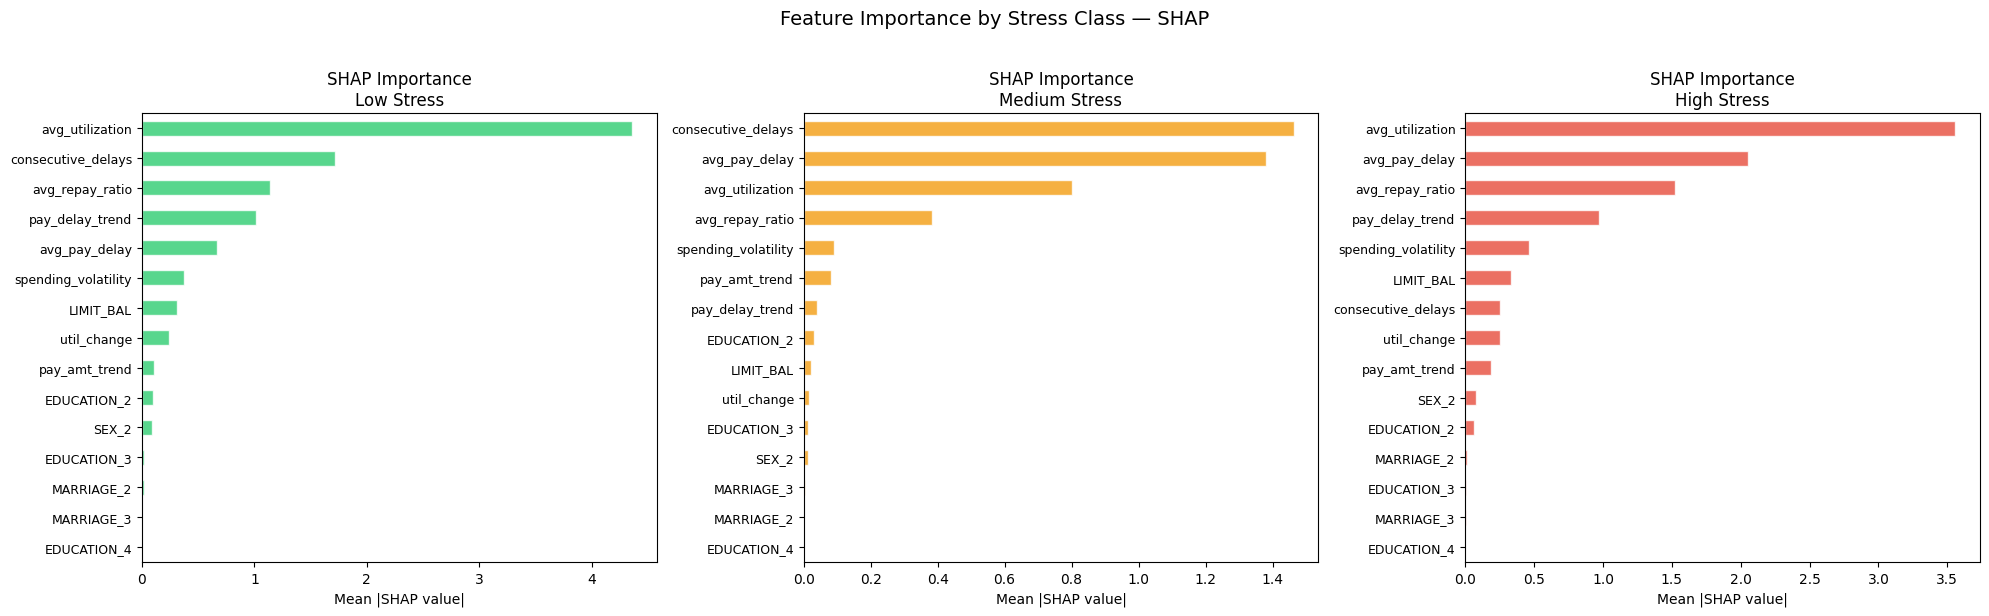


Generating beeswarm plot for High Stress class...


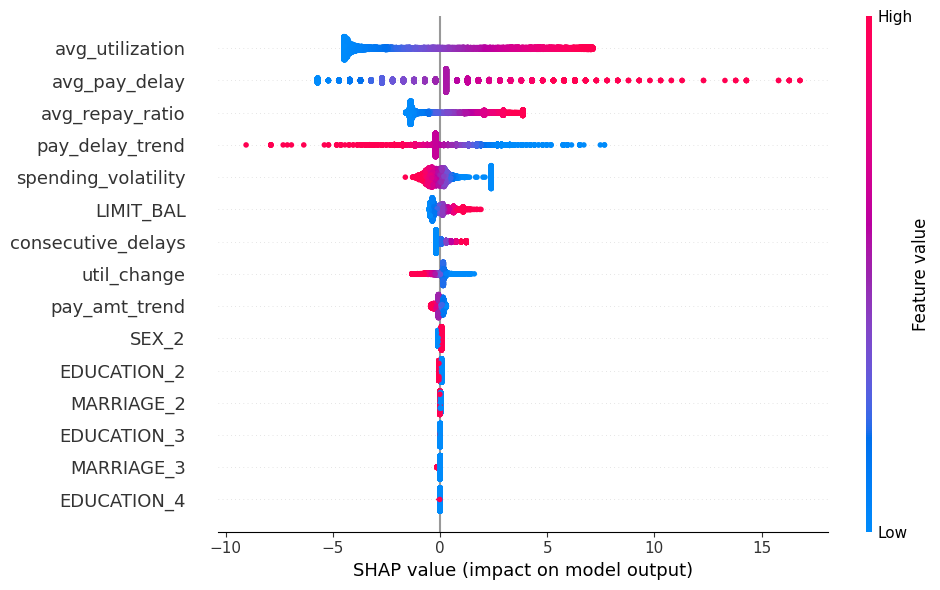


── Top 5 Features per Stress Class ────────────────

  Low Stress:
    avg_utilization           4.3598
    consecutive_delays        1.7192
    avg_repay_ratio           1.1363
    pay_delay_trend           1.0130
    avg_pay_delay             0.6678

  Medium Stress:
    consecutive_delays        1.4636
    avg_pay_delay             1.3816
    avg_utilization           0.8006
    avg_repay_ratio           0.3835
    spending_volatility       0.0917

  High Stress:
    avg_utilization           3.5592
    avg_pay_delay             2.0493
    avg_repay_ratio           1.5198
    pay_delay_trend           0.9731
    spending_volatility       0.4636

── Sample Customer Explanation ─────────────────────
Customer index 0 from test set:
  Actual stress    : Medium
  Predicted stress : Medium

  Top contributing features:
    consecutive_delays        +4.2872  (increases stress probability)
    avg_pay_delay             -2.8904  (decreases stress probability)
    avg_utilization           +

In [20]:
print("=" * 55)
print("EXPLAINABILITY — SHAP ANALYSIS")
print("=" * 55)

# LinearExplainer is correct for Logistic Regression
explainer = shap.LinearExplainer(
    best_lr,
    X_train_scaled,
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(X_test_scaled)

print(f"✓ SHAP values computed")
print(f"  Shape: {np.array(shap_values).shape}")
print(f"  One set of SHAP values per class "
      f"(Low, Medium, High)")

# ── Plot 1: Global feature importance (all classes) ───
print("\nGenerating SHAP summary plots...")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
class_names = ['Low Stress', 'Medium Stress', 'High Stress']
colors_list = ['#2ecc71', '#f39c12', '#e74c3c']

for i, (cname, color) in enumerate(
        zip(class_names, colors_list)):
    # Mean absolute SHAP per feature for this class
    mean_shap = np.abs(shap_values[:, :, i]).mean(axis=0)
    feat_imp  = pd.Series(
        mean_shap, index=feature_columns
    ).sort_values(ascending=True)

    feat_imp.plot(
        kind='barh', ax=axes[i],
        color=color, alpha=0.8, edgecolor='white'
    )
    axes[i].set_title(f'SHAP Importance\n{cname}',
                      fontsize=12)
    axes[i].set_xlabel('Mean |SHAP value|')
    axes[i].tick_params(axis='y', labelsize=9)

plt.suptitle('Feature Importance by Stress Class — SHAP',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Plot 2: Beeswarm for High Stress class ────────────
print("\nGenerating beeswarm plot for High Stress class...")
shap.summary_plot(
    shap_values[:, :, 2],
    X_test_scaled,
    feature_names=feature_columns,
    plot_type='dot',
    max_display=15,
    show=True,
    plot_size=(10, 6),
    title='SHAP Beeswarm — High Stress Class'
)

# ── Top features per class ────────────────────────────
print("\n── Top 5 Features per Stress Class ────────────────")
for i, cname in enumerate(class_names):
    mean_shap = np.abs(shap_values[:, :, i]).mean(axis=0)
    top5 = pd.Series(
        mean_shap, index=feature_columns
    ).nlargest(5)
    print(f"\n  {cname}:")
    for feat, val in top5.items():
        print(f"    {feat:<25} {val:.4f}")

# ── Single customer explanation ───────────────────────
print("\n── Sample Customer Explanation ─────────────────────")
print("Customer index 0 from test set:")
print(f"  Actual stress    : "
      f"{stress_map[y_test.iloc[0]]}")
print(f"  Predicted stress : "
      f"{stress_map[y_pred[0]]}")
print(f"\n  Top contributing features:")

customer_shap = shap_values[0, :, y_pred[0]]
customer_feat = pd.Series(
    customer_shap, index=feature_columns
).sort_values(key=abs, ascending=False)

for feat, val in customer_feat.head(5).items():
    direction = 'increases' if val > 0 else 'decreases'
    print(f"    {feat:<25} {val:+.4f}  "
          f"({direction} stress probability)")

## Phase 7 — Save the Model

In [21]:
import joblib
import os
import json
from datetime import datetime

print("=" * 55)
print("PHASE 7 — SAVE MODEL + FINAL SUMMARY")
print("=" * 55)

# ── Create models directory ───────────────────────────
os.makedirs('../models', exist_ok=True)
os.makedirs('../models/logistic_regression', exist_ok=True)

# ── Save model artifacts ──────────────────────────────
joblib.dump(
    best_lr,
    '../models/logistic_regression/model.pkl'
)
joblib.dump(
    scaler,
    '../models/logistic_regression/scaler.pkl'
)
joblib.dump(
    feature_columns,
    '../models/logistic_regression/feature_columns.pkl'
)
print("✓ Model saved   → models/logistic_regression/model.pkl")
print("✓ Scaler saved  → models/logistic_regression/scaler.pkl")
print("✓ Features saved→ models/logistic_regression/feature_columns.pkl")

# ── Save model metadata as JSON ───────────────────────
metadata = {
    "model"          : "Logistic Regression",
    "task"           : "Stress Detection (Task A)",
    "classes"        : ["Low", "Medium", "High"],
    "date_trained"   : datetime.now().strftime("%Y-%m-%d"),
    "best_params"    : {
        str(k): str(v) 
        for k, v in random_search.best_params_.items()
    },
    "cv_f1_weighted" : round(
        float(random_search.best_score_), 4
    ),
    "test_metrics"   : {
        "weighted_f1"  : round(float(f1_weighted), 4),
        "macro_f1"     : round(float(f1_macro), 4),
        "f1_low"       : round(float(f1_per_class[0]), 4),
        "f1_medium"    : round(float(f1_per_class[1]), 4),
        "f1_high"      : round(float(f1_per_class[2]), 4),
        "accuracy"     : round(
            float((y_pred == y_test).mean()), 4
        ),
        "error_rate"   : round(
            float((y_pred != y_test).mean()), 4
        )
    },
    "features_used"  : feature_columns,
    "top_shap_features" : {
        "Low"    : ["avg_utilization", "consecutive_delays",
                    "avg_repay_ratio"],
        "Medium" : ["consecutive_delays", "avg_pay_delay",
                    "avg_utilization"],
        "High"   : ["avg_utilization", "avg_pay_delay",
                    "avg_repay_ratio"]
    },
    "notes" : [
        "Baseline model — lower bound for comparison",
        "Medium class hardest to classify (boundary ambiguity)",
        "Demographic features near-zero SHAP (fair model)",
        "Performance ceiling at ~0.863 CV F1 (linear boundary)",
        "No overfitting — train/CV gap of 0.0004"
    ]
}

with open('../models/logistic_regression/metadata.json', 
          'w') as f:
    json.dump(metadata, f, indent=2)
print("✓ Metadata saved→ "
      "models/logistic_regression/metadata.json")

# ── Final printed summary ─────────────────────────────
print(f"""
╔══════════════════════════════════════════════════════╗
║        LOGISTIC REGRESSION — COMPLETE SUMMARY        ║
╠══════════════════════════════════════════════════════╣
║  Task          : Stress Detection (3-class)          ║
║  Dataset       : UCI Credit Card (30,000 customers)  ║
╠══════════════════════════════════════════════════════╣
║  PERFORMANCE                                         ║
║  CV F1 (5-fold): {random_search.best_score_:.4f}                       ║
║  Test F1       : {f1_weighted:.4f}                       ║
║  Test Accuracy : {(y_pred==y_test.values).mean():.4f}                       ║
║  Error Rate    : {(y_pred!=y_test.values).mean():.4f}                       ║
╠══════════════════════════════════════════════════════╣
║  PER CLASS F1                                        ║
║  Low    : {f1_per_class[0]:.4f}  (easiest class)            ║
║  Medium : {f1_per_class[1]:.4f}  (hardest — boundary)       ║
║  High   : {f1_per_class[2]:.4f}  (good performance)         ║
╠══════════════════════════════════════════════════════╣
║  BEST PARAMS                                         ║
║  C=0.5, l2, saga, balanced, tol=0.0001              ║
╠══════════════════════════════════════════════════════╣
║  KEY SHAP INSIGHTS                                   ║
║  avg_utilization  → top feature for Low + High       ║
║  consecutive_delays → dominant for Medium            ║
║  Demographics     → near-zero impact (fair model)   ║
╠══════════════════════════════════════════════════════╣
║  ROLE IN PROJECT                                     ║
║  Baseline Model 1 — sets lower bound at 0.8677 F1   ║
║  RF + Joint Model must beat this to justify          ║
║  the added complexity                                ║
╚══════════════════════════════════════════════════════╝
""")

PHASE 7 — SAVE MODEL + FINAL SUMMARY
✓ Model saved   → models/logistic_regression/model.pkl
✓ Scaler saved  → models/logistic_regression/scaler.pkl
✓ Features saved→ models/logistic_regression/feature_columns.pkl
✓ Metadata saved→ models/logistic_regression/metadata.json

╔══════════════════════════════════════════════════════╗
║        LOGISTIC REGRESSION — COMPLETE SUMMARY        ║
╠══════════════════════════════════════════════════════╣
║  Task          : Stress Detection (3-class)          ║
║  Dataset       : UCI Credit Card (30,000 customers)  ║
╠══════════════════════════════════════════════════════╣
║  PERFORMANCE                                         ║
║  CV F1 (5-fold): 0.8633                       ║
║  Test F1       : 0.8677                       ║
║  Test Accuracy : 0.8653                       ║
║  Error Rate    : 0.1347                       ║
╠══════════════════════════════════════════════════════╣
║  PER CLASS F1                                        ║
║  Low    : 0.